In [1]:
# import basics
import numpy as np
from random import randint
from math import gcd
# import Qiskit tools
from qiskit import Aer, transpile, assemble, execute
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
# import plot tools
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [2]:
def c_amod15(a, power):
    """Controlled multiplication by a mod 15"""
    if a not in [2,4,7,8,11,13]:
        raise ValueError("'a' must be 2,4,7,8,11 or 13")
    U = QuantumCircuit(4)
    for _iteration in range(power):
        if a in [2,13]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a in [7,8]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [4, 11]:
            U.swap(1,3)
            U.swap(0,2)
        if a in [7,11,13]:
            for q in range(4):
                U.x(q)
    U = U.to_gate()
    U.name = f"{a}^{power}mod15"
    c_U = U.control()
    return c_U

In [3]:
# Specify variables
N_COUNT = 8  # number of counting qubits
a = 7

In [4]:
def qft_dagger(n):
    """n-qubit QFTdagger the first n qubits in circ"""
    qc = QuantumCircuit(n)
    # Don't forget the Swaps!
    for qubit in range(n//2):
        qc.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc.cp(-np.pi/float(2**(j-m)), m, j)
        qc.h(j)
    qc.name = "QFT†"
    return qc

In [5]:
# Create QuantumCircuit with N_COUNT counting qubits
# plus 4 qubits for U to act on
qc = QuantumCircuit(N_COUNT + 4, N_COUNT)

# Initialize counting qubits
# in state |+>
for q in range(N_COUNT):
    qc.h(q)

# And auxiliary register in state |1>
qc.x(N_COUNT)

# Do controlled-U operations
for q in range(N_COUNT):
    qc.append(c_amod15(a, 2**q),
             [q] + [i+N_COUNT for i in range(4)])

# Do inverse-QFT
qc.append(qft_dagger(N_COUNT), range(N_COUNT))

# Measure circuit
qc.measure(range(N_COUNT), range(N_COUNT))
qc.draw(output = 'latex_source', filename = 'bla.tex')  # -1 means 'do not fold'

'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{\n\\Qcircuit @C=1.0em @R=0.2em @!R { \\\\\n\t \t\\nghost{{q}_{0} :  } & \\lstick{{q}_{0} :  } & \\gate{\\mathrm{H}} & \\ctrl{8} & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\multigate{7}{\\mathrm{QFT†}}_<<<{0} & \\meter & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1} :  } & \\lstick{{q}_{1} :  } & \\gate{\\mathrm{H}} & \\qw & \\ctrl{7} & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\ghost{\\mathrm{QFT†}}_<<<{1} & \\qw & \\meter & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{2} :  } & \\lstick{{q}_{2} :  } & \\gate{\\mathrm{H}} & \\qw & \\qw & \\ctrl{6} & \\qw & \\qw & \\qw & \\qw & \\qw & \\ghost{\\mathrm{QFT†}}_<<<{2} & \\qw & \\qw & \\meter & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{3} :  } & \\lstick{{q}_{3} :  } & \\gate{\\mathrm{H}} &

In [8]:
backend = Aer.get_backend('qasm_simulator') # simulator
job = execute(qc, backend)
result = job.result()
c2 = result.get_counts(qc)
plot_histogram(c2, filename='counts.png')

In [7]:
!pdflatex bla.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020/Debian) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./bla.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-01-09> xparse <2020-03-03>
(/usr/share/texlive/texmf-dist/tex/latex/standalone/standalone.cls
Document Class: standalone 2018/03/26 v1.3a Class to compile TeX sub-files stan
dalone
(/usr/share/texlive/texmf-dist/tex/latex/tools/shellesc.sty)
(/usr/share/texlive/texmf-dist/tex/generic/iftex/ifluatex.sty
(/usr/share/texlive/texmf-dist/tex/generic/iftex/iftex.sty))
(/usr/share/texlive/texmf-dist/tex/latex/xkeyval/xkeyval.sty
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/xkeyval.tex
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/xkvutils.tex
(/usr/share/texlive/texmf-dist/tex/generic/xkeyval/keyval.tex))))
(/usr/share/texlive/texmf-dist/tex/latex/standalone/standalone.cfg)
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04

In [10]:
x = np.arange(15)
y = [np.mod(13**i, 15) for i in x]

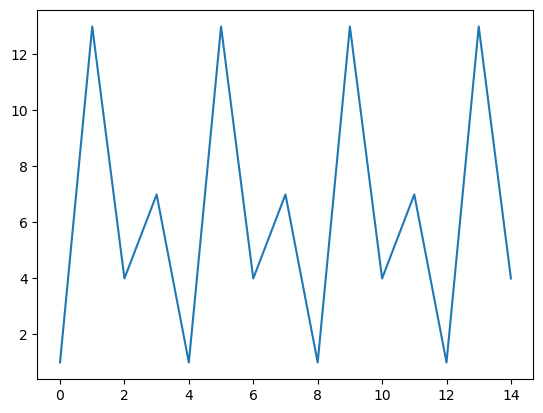

In [11]:
plt.plot(x,y)